# Часть 1. Проверка гипотезы в Python и составление аналитической записки

## Часть 1. Проверка гипотезы и аналитическая записка

Данные пользователей двух городов (Москва и Санкт-Петербург) с суммарным временем их активности в приложении для чтения и прослушивания книг. Нужно проверить гипотезу о том, что пользователи Санкт-Петербурга в среднем проводят в приложении больше времени, чем пользователи Москвы, с помощью односторонней проверки гипотезы для двух выборок:

- **H₀:** среднее время активности в Санкт-Петербурге не больше, чем в Москве.
- **H₁:** среднее время активности в Санкт-Петербурге больше, и различие статистически значимо.

По итогам — аналитическая записка с выбранным тестом, уровнем значимости, p-value, интерпретацией результата и возможными причинами.

# Исследование вовлечённости пользователей: Москва и Санкт-Петербург

- Автор: Дорохина Екатерина

## Цели и задачи проекта

Цель проекта — понять, являются ли жители Петербурга более вовлеченными, а значит и лояльными, чем жители Москвы. Проводят ли жители северной столицы больше времени за чтением или прослушиванием книг.

## Описание данных

**Данные содержат следующие столбцы:**<br>
* city — город пользователя (Москва или Сантк-Петербург);<br>
* puid — идентификатор пользователя;<br>
* hours — общее количество часов активности пользователя.

## Содержание

---

* Загрузка и предобработка данных (проверка дубликатов, пересечений по городам, выбросов)<br>
* Сравнение групп (статистики, распределение)<br>
* Проверка гипотезы тестом Манна-Уитни<br>
* Аналитическая записка с выводами<br>

## 1. Загрузка данных и знакомство с ними

Загрузка данных пользователей двух городов с их активностью (суммарным временем чтения и прослушивания).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from scipy.stats import ttest_ind, mannwhitneyu
import numpy as np

In [2]:
df = pd.read_csv('yandex_knigi_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


Пропусков нет. Есть странная безымянная колонка — проверю ее далее. Айди пользователей переведу в object.

In [3]:
df.head(10)

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434
5,5,Москва,352567,8.206369
6,6,Москва,439493,0.857758
7,7,Москва,494541,0.035072
8,8,Москва,647235,12.000076
9,9,Москва,656480,0.973032


Безымянная колонка дублирует индексы — она не будет нужна в работе.<br>
Длительность часов далее буду округлять.

In [4]:
# Удаляю дублирующую колонку
df.drop('Unnamed: 0', axis=1, inplace=True, errors='ignore')

# Переведу айдишники в 'object', математические действия с ними делать не будет нужно
df['puid'] = df['puid'].astype('object')
df.head(3)

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906


In [5]:
df.duplicated().sum()

0

In [6]:
df['puid'].nunique()

8540

Явных дубликатов нет. Но число уникальных айди отличается от кол-ва строк. Следовательно, часть пользователей может находиться в обоих городах. Их нужно проверить и отсеять из выборок.

In [7]:
# Сколько пользователей по городам
df.groupby('city')['puid'].nunique()

city
Москва             6234
Санкт-Петербург    2550
Name: puid, dtype: int64

In [8]:
# Найдем пересекающихся
intersection = (df
 .groupby('puid')
 .agg({'city':'nunique'})
 .query('city > 1'))
intersection

,city
puid,
2637041,2
9979490,2
10597984,2
10815097,2
13626259,2
...,...
1130000018516717,2
1130000018954257,2
1130000020425037,2


In [9]:
# Удалим пересекающихся
df = df[~df['puid'].isin(intersection.index)]

In [10]:
# Проверим изменения 
df.groupby('city')['puid'].nunique()

city
Москва             5990
Санкт-Петербург    2306
Name: puid, dtype: int64

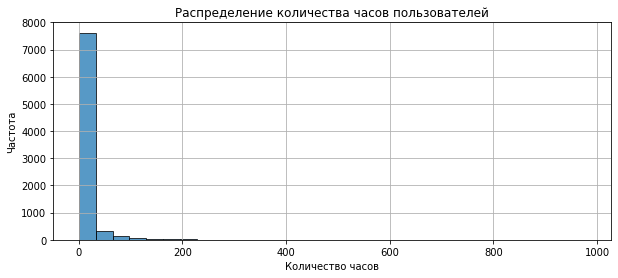

In [11]:
# Проверим необычные значения
plt.figure(figsize=(10, 4))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['hours'].plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
)

# Настраиваем оформление графика
plt.title('Распределение количества часов пользователей')
plt.xlabel('Количество часов')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show() 

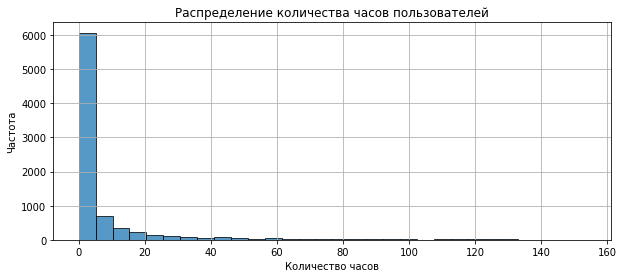

In [12]:
# Проверим необычные значения

clean_hours = df[df['hours'] <= 
df['hours'].quantile(0.99)]['hours']

plt.figure(figsize=(10, 4))

# Строим гистограмму с помощью pandas через plot(kind='hist')
clean_hours.plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
)

# Настраиваем оформление графика
plt.title('Распределение количества часов пользователей')
plt.xlabel('Количество часов')
plt.ylabel('Частота')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show() 

In [13]:
df = df[df['hours'] <= df['hours'].quantile(0.99)]

# Проверим изменения 
df.groupby('city')['puid'].nunique()

city
Москва             5929
Санкт-Петербург    2284
Name: puid, dtype: int64

In [14]:
# Сравним статистики и распределение
df.groupby('city')['hours'].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Москва,5929.0,8.064964,19.733973,0.000022,0.055492,0.856322,5.639621,153.639891
Санкт-Петербург,2284.0,8.377901,19.723539,0.000025,0.057032,0.852310,5.672186,152.338086


Посчитала число уникальных юзеров по городам, нашла и удалила 244 человека, которые находились в обоих городах.<br> Отсекла 99% процентилем существенные выбросы, которые доходили до 1000 часов в месяц на человека.<br>
<br>
Аудитория Москвы все еще более, чем в 2 раза больше Питера. <br>
Но статистики обоих городов очень близки друг к другу — значит, аудитории сопоставимы.<br>
**Важный момент** — std (19,7) намного больше среднего (8,06-8,38). Это признак сильно скошенного распределения с длинным правым хвостом, что подтверждается и дистограммой выше.<br>
<br>
Так как есть скошенность вправо и размеры аудиторий в Москве и Питере разные, больше всего нам сейчас подойдет тест Манна-Уитни.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [15]:
metric_a = df[df['city'] == 'Санкт-Петербург']['hours']  # a = Петербург
metric_b = df[df['city'] == 'Москва']['hours']            # b = Москва

alpha = 0.05 

# Применяем тест Манна-Уитни
stat_mw, p_value_mw = mannwhitneyu(
    metric_a, 
    metric_b, 
    alternative='greater' # Альтернативная гипотеза односторонняя
) 

if p_value_mw > alpha:
    print(f'pvalue={p_value_mw} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'pvalue={p_value_mw} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')

pvalue=0.43450391335194727 > 0.05
Нулевая гипотеза находит подтверждение!


Статистически значимого превышения активности петербуржцев над москвичами не обнаружено.<br>
<br>
Это согласуется с данными в описательных статистиках: средние (8,06 и 8,38) и медианы (0,856 и 0,852) очень близки между городами. <br>
Разница в среднем была небольшой и укладывается в рамки случайного разброса, а не отражает существенное различие между городами.<br>

## 3. Аналитическая записка

* Для проверки гипотезы выбрала непараметрический тест Манна-Уитни, потому что распределение hours оказалось сильно скошенным (с длинным правым хвостом и выбросами) и не соответствовало условию нормальности для t-теста. Уровень статистической значимости выбрала стандартный α = 0.05, проверка гипотезы — односторонняя.<br>
<br>
* Результат теста: p-value = 0.4345.<br>
<br>
* Так как p-value значительно больше уровня значимости, нет оснований отвергать нулевую гипотезу.<br>
Статистически значимых различий в средней активности пользователей Москвы и Санкт-Петербурга не выявлено.<br>
<br>
* Почему разницы может и не быть.<br>
Оба города — крупные с сопоставимым образом жизни, занятостью, доступом к интернету — это вполне могут быть очень похожие люди.<br>
Разница в LTV (которую мы нашли раньше) могла быть связана не с длительностью активности, а другим фактором — например, числом активных месяцев или оттоком подписчиков.<br>
Сильный разброс (std 19,7 при среднем 8) означает, что индивидуальные различия между пользователями внутри каждого города гораздо больше, чем различия между городами — то есть эффект от индивидуальных привычек  перекрывает любой возможный эффект конкретного города.

----

# Часть 2. Анализ результатов A/B-тестирования

## Часть 2. Анализ результатов A/B-тестирования

Интернет-магазин геймифицированных товаров для здорового образа жизни планирует расширять ассортимент, но прежде хочет упростить интерфейс сайта: по отзывам, текущая версия слишком сложна для пользователей. Магазин разработал новую версию сайта и протестировал её на части аудитории, ожидая роста числа покупок.

Задача — оценить корректность проведения A/B-теста и проанализировать его результаты. В распоряжении: данные о действиях пользователей и их распределении по группам, а также техническое задание теста.

## 1. Цели исследования

Мы имеем результаты проведенного теста со следующими гипотезами:<br>
* Н0: Упрощение интерфейса сайта не приведет к изменению конверсии из зарегистрированных поьзователей в покупателей.<br>
* Н1: Упрощение интерфейса сайта приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта.<br>
<br>
Необходимо оценить корректность проведения теста и проанализировать его результаты.<br>
<br>
Поскольку речь о процентных изменениях — проводим Z-тест пропорций.

## 2. Загрузка данных и оценка их целостности

In [16]:
participants = pd.read_csv('ab_test_participants.csv')
events = pd.read_csv('ab_test_events.zip', parse_dates=['event_dt'], low_memory=False)

In [17]:
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [18]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


В данных об участниках пропусков нет, типы соответствуют данным.

In [19]:
events.head(10)

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN
5,AA346F4D22148024,2020-12-01 00:01:46,registration,-2.0
6,7EF01D0E72AF449D,2020-12-01 00:02:06,registration,-5.0
7,9A6276AD14B14252,2020-12-01 00:02:20,registration,-2.0
8,9B186A3B1A995D36,2020-12-01 00:02:37,registration,-3.5
9,9A6276AD14B14252,2020-12-01 00:02:53,login,NaN


In [20]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


В данных о событиях в основных колонках пропусков нет, типы соответствуют данным.<br>В дополнительной колонке данные заполнены менее, чем на треть. Мы оставим эти пропуски как есть, потому что заполнять их в данном случае будет некорректно.

## 3. Оценка корректности проведения теста (таблица участников)

Выделяем пользователей изучаемого теста и проверяем: соответствие ТЗ, равномерность распределения по группам, отсутствие пересечений с конкурирующим тестом.

In [21]:
share = participants[participants['ab_test'] == 'interface_eu_test'].groupby('group')['user_id'].nunique()

In [22]:
share_a = share['A']
share_b = share['B']

diff = (share_b - share_a) / share_b

print(f"Число пользователей в группе A: {share_a:.0f}")
print(f"Число успешных первых сессий в группе B: {share_b:.0f}")
print(f"Разница (B − A): {diff:.4f}")

Число пользователей в группе A: 5383
Число успешных первых сессий в группе B: 5467
Разница (B − A): 0.0154


In [23]:
# Найдем пересекающихся
intersection = (participants
 .groupby('user_id')
 .agg({'group':'nunique'})
 .query('group > 1'))
intersection

,group
user_id,
001064FEAAB631A1,2
00341D8401F0F665,2
00EFA157F7B6E1C4,2
01B9975CAE144B78,2
020A95B66F363AFB,2
...,...
FC37CBE8211E02A8,2
FCF70F6E1871BD78,2
FE82D7FC50D4155B,2


Пересекающиеся пользователи найдены и удалены.<br>
Группы разделены корректно. Расхождение в численности незначительное.

### 3.2 Анализ пользовательской активности (таблица событий)

Оставляем только события участников изучаемого теста.

In [24]:
# Участники нашего теста
test_users = participants[participants['ab_test'] == 'interface_eu_test']
test_users.head(5)

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
2,001064FEAAB631A1,A,interface_eu_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac
5,002412F1EB3F6E38,B,interface_eu_test,Mac
6,002540BE89C930FB,B,interface_eu_test,Android


In [25]:
# События участников нашего теста
test_events = events[events['user_id'].isin(test_users['user_id'])]
test_events.head(5)

,user_id,event_dt,event_name,details
64672,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0
64946,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32
67873,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0


Не стала делать через merge — это было бы более громоздко, на мой взгляд.

Горизонт анализа: рассчитываем время от регистрации до события и оставляем события первых семи дней после регистрации.

In [26]:
# Собираем даты регистраций каждого пользователя
reg_dates = test_events[test_events['event_name'] == 'registration'][['user_id', 'event_dt']]
reg_dates = reg_dates.rename(columns={'event_dt': 'reg_date'})
reg_dates.head(5)

,user_id,reg_date
64672,5F506CEBEDC05D30,2020-12-06 14:10:01
64946,51278A006E918D97,2020-12-06 14:37:25
66585,A0C1E8EFAD874D8B,2020-12-06 17:20:22
67873,275A8D6254ACF530,2020-12-06 19:36:54
67930,0B704EB2DC7FCA4B,2020-12-06 19:42:20


In [27]:
# Присоединяем даты регистрации к таблице событий
test_events = test_events.merge(reg_dates, on='user_id', how='left')
test_events.head(5)

,user_id,event_dt,event_name,details,reg_date
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01
1,51278A006E918D97,2020-12-06 14:37:25,registration,-3.8,2020-12-06 14:37:25
2,A0C1E8EFAD874D8B,2020-12-06 17:20:22,registration,-3.32,2020-12-06 17:20:22
3,275A8D6254ACF530,2020-12-06 19:36:54,registration,-0.48,2020-12-06 19:36:54
4,0B704EB2DC7FCA4B,2020-12-06 19:42:20,registration,0.0,2020-12-06 19:42:20


In [28]:
test_events.shape[0]

79715

In [29]:
# У скольких строк нет даты регистрации
test_events['reg_date'].isna().sum()

0

In [30]:
# Сколько дней между событием и регистрацией
test_events['days_since_reg'] = (test_events['event_dt'] - test_events['reg_date']).dt.days

# События в первые 7 дней
test_events = test_events[(test_events['days_since_reg'] >= 0) & (test_events['days_since_reg'] <= 6)]

In [31]:
test_events = test_events.merge(test_users[['user_id', 'group']], on='user_id', how='left')
test_events.shape[0]

68949

In [32]:
test_events.sample(10)

,user_id,event_dt,event_name,details,reg_date,days_since_reg,group
2669,270BFCF7D4DCD4B3,2020-12-07 21:24:29,login,NaN,2020-12-07 21:22:58,0,A
35293,6B1DE4B46F1267CB,2020-12-17 05:50:22,login,NaN,2020-12-16 08:13:02,0,B
21907,B25C948B4347497C,2020-12-14 00:51:18,login,NaN,2020-12-14 00:51:17,0,A
49775,F02A5BA845C564DF,2020-12-20 20:37:46,registration,-0.43,2020-12-20 20:37:46,0,A
46777,04988C5DF189632E,2020-12-20 04:16:07,purchase,4.99,2020-12-14 18:51:43,5,B
63759,3303AC4B6304294E,2020-12-23 20:40:17,login,NaN,2020-12-23 20:32:21,0,A
11114,8F5D7DE5A7B06249,2020-12-11 02:24:38,login,NaN,2020-12-10 02:06:29,1,A
961,1939414A340F28AC,2020-12-07 07:43:17,login,NaN,2020-12-07 07:35:07,0,A
39718,EC9E26D7D9FB307C,2020-12-18 09:39:08,login,NaN,2020-12-18 09:16:53,0,A
40014,3D991B6AE4A4305E,2020-12-18 11:38:40,product_page,NaN,2020-12-17 01:42:28,1,A


Оценка достаточности выборки для статистически значимого результата. Заданные параметры: базовая конверсия — 30%, мощность теста — 80%, достоверность — 95%.

alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень конверсии
mde = 0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p * (1 + mde))

##### Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

##### Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

In [33]:
from statsmodels.stats.power import NormalIndPower

alpha =0.05  
power = 0.8
beta = 1-power
p1 = 0.3
mde=0.03
p2 = p1 + mde

power_analysis = NormalIndPower()
effect_size = (p2 - p1) / np.sqrt((p1*(1-p1) + p2*(1-p2))/2)

sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3759


Необходимый размер выборки для обнаружения эффекта в 3% (относительных) с нужными параметрами — 3759 пользователей на группу.<br>
Фактический размер групп (5383 и 5467) превышает необходимый минимум, поэтому выборки хватит для статистически значимых результатов.

**Считаю количество посетителей, сделавших покупку, и общее количество посетителей в каждой группе.**

In [34]:
total_in_group = test_events.groupby('group')['user_id'].nunique()
total_in_group

group
A    5383
B    5467
Name: user_id, dtype: int64

In [35]:
purchased_in_group = test_events[test_events['event_name'] == 'purchase'].groupby('group')['user_id'].nunique()
purchased_in_group

group
A    1480
B    1600
Name: user_id, dtype: int64

In [36]:
summary = pd.DataFrame({
    'total_users': total_in_group,
    'purchased_users': purchased_in_group
})
summary['conversion'] = round(summary['purchased_users'] / summary['total_users'],2)
summary

,total_users,purchased_users,conversion
group,,,
A,5383,1480,0.27
B,5467,1600,0.29


In [37]:
# Посчитаем разницу между результатами в процентных пунктах
diff = round((summary.loc['B', 'conversion'] - summary.loc['A', 'conversion']) * 100, 2)
diff

2.0

- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

Конверсия в группе B (новый интерфейс) выше, чем в группе A (стрый интерфейс) — 29% и 27%. <br>
Это предварительно согласуется с ожидаемым эффектом изменения интерфейса: новая версия сайта дает чуть более высокую конверсию в покупку. <br>
Расхождение равно всего 2 п.п. — это меньше заложенного MDE, то есть мы ждали чуть более заметный эффект от теста. Поэтому нужна проверка для понимания статистической значимости этого результата. <br>

## 4. Проведите оценку результатов A/B-тестирования:

### Проверка изменения конверсии статистическим тестом

In [38]:
# Проводим Z-тест пропорций

from statsmodels.stats.proportion import proportions_ztest

m_a = summary.loc['A', 'purchased_users']
m_b = summary.loc['B', 'purchased_users']

n_a = summary.loc['A', 'total_users']
n_b = summary.loc['B', 'total_users']

alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller'  # конверсия A меньше конверсии B
)

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest:.4f} > {alpha}')
    print('Нет оснований отвергнуть нулевую гипотезу: статистически значимой разницы конверсий не обнаружено.')
else:
    print(f'pvalue={p_value_ztest:.4f} < {alpha}')
    print('Нулевая гипотеза отвергается: конверсия в группе B статистически значимо выше, чем в группе A.')

pvalue=0.0203 < 0.05
Нулевая гипотеза отвергается: конверсия в группе B статистически значимо выше, чем в группе A.


### Выводы по результатам A/B-тестирования

Статистический тест показал значимый результат: p-value = 0.0203, это существенно меньше заданного уровня значимости 0.05. <br>
Нулевая гипотеза отвергается — конверсия в группе B (новый интерфейс) статистически значимо выше, чем в группе A (старый интерфейс), 29% против 27%. Прирост составил 2 процентных пункта.<br>

Ожидаемый эффект случился: новая версия интерфейса повысила конверсию, и разница не случайна. Ожидаемый результат был выше на 1 процентный пункт, значит, тест был достаточно мощным, чтобы его обнаружить. 